# Простая Q-learning стратегия без нейросетей

- Дискретное состояние: (trend, rsi_bucket, position)
- Действия: 0=Hold, 1=Go Long, 2=Go Flat, 3=Go Short
- Вознаграждение: дневное dPnL с комиссией за смену позиции.


In [1]:
import math
import random
from collections import defaultdict
from dataclasses import dataclass
from typing import Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Утилиты фичей

In [2]:
def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    avg_gain = up.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = down.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss.replace(0, np.nan))
    rsi = 100 - (100 / (1 + rs))
    return rsi.fillna(50)


def discretize_rsi(x: float) -> int:
    # 0: oversold, 1: neutral, 2: overbought
    if x <= 35:
        return 0
    elif x >= 65:
        return 2
    return 1


def sign3(x: float, tol: float = 1e-8) -> int:
    if x > tol:
        return 1
    if x < -tol:
        return -1
    return 0

## Синтетические данные (или подставьте свой CSV или загрузить данные из yahoo.finance)


In [3]:
def make_synthetic(n=1800, seed=7):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    mu = 0.0003                        # константный дрейф ~0.03%/день
    seasonal = 0.002 * np.sin(2*np.pi*t/60)
    noise = rng.normal(0, 0.01, n)
    logret = mu + seasonal + noise
    price = 100 * np.exp(np.cumsum(logret))
    df = pd.DataFrame({"Close": price})
    df.index = pd.date_range("2020-01-01", periods=n, freq="D")
    return df

## Окружение (среда) торговли

In [4]:
@dataclass
class EnvConfig:
    sma_fast: int = 10
    sma_slow: int = 30
    fee_per_turn: float = 0.0005  # комиссия/проскальзывание (0.05%)
    reward_mode: str = "diff"     # "diff" (dPnL) или "logret_pos"
    start_offset: int = 50        # чтобы индикаторы успели стабилизироваться

class TradingEnv:
    """
    Простой средний-реверсионный/трендовый симулятор:
    - Цена = df['Close']
    - Позиция ∈ {-1, 0, +1}
    - Действия: 0=Hold, 1=Long, 2=Flat, 3=Short
    - Награда: изменение equity с комиссией при смене позиции
    """
    def __init__(self, df: pd.DataFrame, cfg: EnvConfig):
        self.df = df.copy(deep=True)
        self.cfg = cfg
        self._build_features()
        self.reset()

    def _build_features(self):
        self.df["SMA_F"] = self.df["Close"].rolling(self.cfg.sma_fast, min_periods=1).mean()
        self.df["SMA_S"] = self.df["Close"].rolling(self.cfg.sma_slow, min_periods=1).mean()
        self.df["Trend"] = self.df["SMA_F"] - self.df["SMA_S"]
        self.df["RSI"] = rsi(self.df["Close"], period=14)
        self.df["LogRet"] = np.log(self.df["Close"]).diff().fillna(0.0)
        # пригодится для быстрой оценки PnL
        self.df["Diff"] = self.df["Close"].diff().fillna(0.0)

        self.start_t = self.cfg.start_offset
        self.end_t = len(self.df) - 2  # чтобы иметь t+1

    def reset(self):
        self.t = self.start_t
        self.pos = 0   # -1 / 0 / +1
        self.equity = 1.0
        return self._state()

    def _state(self) -> Tuple[int, int, int]:
        tr = sign3(float(self.df["Trend"].iloc[self.t]))
        rsi_b = discretize_rsi(float(self.df["RSI"].iloc[self.t]))
        pos = self.pos  # -1,0,1
        return (tr, rsi_b, pos + 1)  # смещение, чтобы было 0/1/2

    def step(self, action: int):
        """
        Выполняем действие на шаге t, получаем награду по переходу t -> t+1
        """
        prev_pos = self.pos
        # map action -> target position
        if action == 1:
            self.pos = 1
        elif action == 2:
            self.pos = 0
        elif action == 3:
            self.pos = -1
        elif action == 0:
            pass
        else:
            raise ValueError("bad action")

        fee = 0.0
        if self.pos != prev_pos:
            # комиссия/проскальзывание пропорциональна абсолютной смене плеча
            fee = self.cfg.fee_per_turn * abs(self.pos - prev_pos)

        # награда за движение цены от t к t+1 относительно позиции ДО конца шага
        if self.cfg.reward_mode == "diff":
            d_price = float(self.df["Diff"].iloc[self.t + 1])
            reward = self.pos * d_price / float(self.df["Close"].iloc[self.t])
        else:
            # лог-доходность * позиция
            reward = self.pos * float(self.df["LogRet"].iloc[self.t + 1])

        reward -= fee

        # обновляем equity (геометрически)
        # self.equity *= (1.0 + reward)
        self.equity *= math.exp(reward)

        self.t += 1
        done = self.t >= self.end_t
        return self._state(), reward, done, {"equity": self.equity, "fee": fee}

    @property
    def n_actions(self) -> int:
        return 4

## Q-learning агент

In [5]:
@dataclass
class QCfg:
    alpha: float = 0.15     # скорость обучения
    gamma: float = 0.95     # дисконт
    eps_start: float = 0.7  # начальная eps
    eps_end: float = 0.05   # конечная eps
    eps_decay_episodes: int = 200  # к какому эпизоду спустить eps
    episodes: int = 400
    seed: int = 123
    

class QAgent:
    def __init__(self, n_actions: int, cfg: QCfg):
        self.n_actions = n_actions
        self.cfg = cfg
        random.seed(cfg.seed)
        np.random.seed(cfg.seed)
        self.Q = defaultdict(float)  # key=(state_tuple, action) -> value

    def _eps(self, ep: int) -> float:
        if ep >= self.cfg.eps_decay_episodes:
            return self.cfg.eps_end
        frac = ep / max(1, self.cfg.eps_decay_episodes)
        return self.cfg.eps_start + (self.cfg.eps_end - self.cfg.eps_start) * frac

    def act(self, state: Tuple[int, int, int], eps: float) -> int:
        if random.random() < eps:
            return random.randrange(self.n_actions)
        # greedy
        vals = [self.Q[(state, a)] for a in range(self.n_actions)]
        return int(np.argmax(vals))

    def update(self, s, a, r, s_next):
        # Q(s,a) <- Q(s,a) + alpha * (r + gamma*max_a' Q(s',a') - Q(s,a))
        q = self.Q[(s, a)]
        max_next = max(self.Q[(s_next, ap)] for ap in range(self.n_actions))
        td = r + self.cfg.gamma * max_next - q
        self.Q[(s, a)] = q + self.cfg.alpha * td

## Метрики и бектест

In [6]:
def sharpe_ratio(returns: np.ndarray, risk_free: float = 0.0) -> float:
    if returns.std() == 0:
        return 0.0
    # дневной Sharpe; для дневных данных умножь на sqrt(252)
    return (returns.mean() - risk_free) / (returns.std() + 1e-12) * math.sqrt(252)

def max_drawdown(equity_curve: np.ndarray) -> float:
    peak = -np.inf
    mdd = 0.0
    for x in equity_curve:
        peak = max(peak, x)
        dd = (x - peak) / peak if peak > 0 else 0.0
        mdd = min(mdd, dd)
    return mdd  # отрицательное число, например -0.25

## Тренировка, оцена, графики

In [12]:
def train_on_series(df: pd.DataFrame,
                    env_cfg: EnvConfig,
                    q_cfg: QCfg):
    env = TradingEnv(df, env_cfg)
    agent = QAgent(env.n_actions, q_cfg)

    equity_by_ep = []
    for ep in range(q_cfg.episodes):
        eps = agent._eps(ep)
        s = env.reset()
        done = False
        while not done:
            a = agent.act(s, eps)
            s_next, r, done, info = env.step(a)
            agent.update(s, a, r, s_next)
            s = s_next
        equity_by_ep.append(info["equity"])

        if (ep + 1) % 50 == 0:
            print(f"Episode {ep+1}/{q_cfg.episodes}: equity={info['equity']:.3f}, eps={eps:.3f}")

    return agent, equity_by_ep, env


def run_greedy_episode(env: TradingEnv, agent: QAgent):
    s = env.reset()
    done = False
    equity_trace = [env.equity]
    rets = []
    actions, positions = [], [env.pos]
    while not done:
        a = agent.act(s, eps=0.0)  # чисто жадно
        s_next, r, done, info = env.step(a)
        rets.append(r)
        actions.append(a)
        positions.append(env.pos)
        equity_trace.append(info["equity"])
        s = s_next
    return np.array(equity_trace), np.array(rets), np.array(actions), np.array(positions)


def plot_equity(equity_trace: np.ndarray, title="Equity"):
    plt.figure(figsize=(10, 4))
    plt.plot(equity_trace)
    plt.title(title)
    plt.xlabel("Steps")
    plt.ylabel("Equity")
    plt.grid = True
    plt.tight_layout()
    plt.show()

## Запуск и тестирование

In [8]:
# 1) ДАННЫЕ: вариант А — синтетика
df = make_synthetic(n=1800, seed=7)

# --- вариант Б (реальные данные с диска) ---
# df = pd.read_csv("data.csv", parse_dates=["Date"])
# df = df.rename(columns={"Date":"Date","Close":"Close"})[["Date","Close"]].dropna()
# df = df.set_index("Date").sort_index()

env_cfg = EnvConfig(
    sma_fast=10,
    sma_slow=30,
    fee_per_turn=0.0005,   # 5 б.п. за смену позиции
    reward_mode="LogRet",
    start_offset=50
)
q_cfg = QCfg(
    alpha=0.15,
    gamma=0.95,
    eps_start=0.7,
    eps_end=0.05,
    eps_decay_episodes=200,
    episodes=400,
    seed=123
)

In [9]:
df.head()

,Close
2020-01-01,100.031235
2020-01-02,100.381608
2020-01-03,100.178485
2020-01-04,99.381458
2020-01-05,99.040844


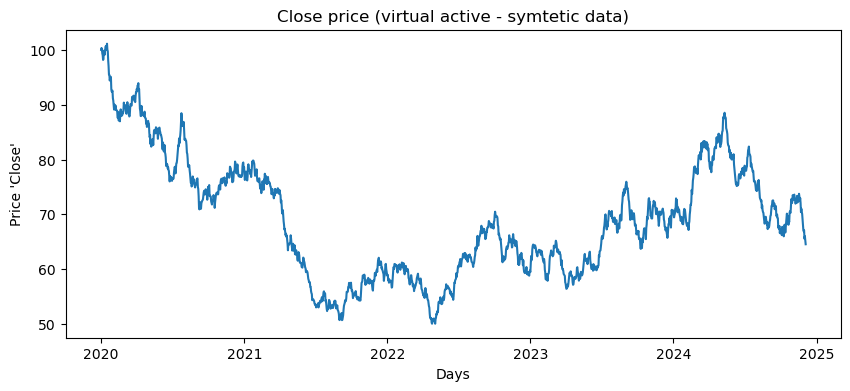

In [10]:
plt.subplots(figsize=(10, 4))
plt.plot(df)
plt.title("Close price (virtual active - symtetic data)")
plt.ylabel("Price 'Close'")
plt.xlabel("Days")
plt.grid=False
plt.show()

Episode 50/400: equity=0.545, eps=0.541
Episode 100/400: equity=0.644, eps=0.378
Episode 150/400: equity=0.634, eps=0.216
Episode 200/400: equity=0.872, eps=0.053
Episode 250/400: equity=0.843, eps=0.050
Episode 300/400: equity=0.999, eps=0.050
Episode 350/400: equity=0.920, eps=0.050
Episode 400/400: equity=0.953, eps=0.050

После обучения: медианная equity по эпизодам = 0.894
Финальная equity (greedy): 1.0330
Sharpe (дневной): 0.442
Max Drawdown: -1.055%


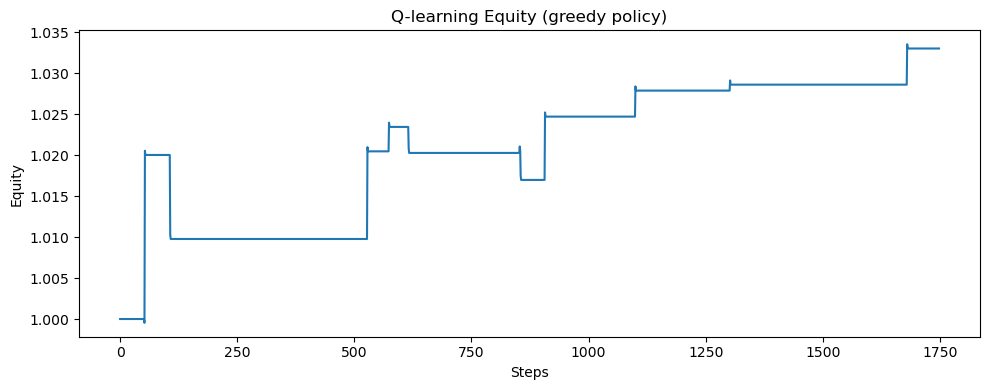

In [13]:
agent, equity_by_ep, env = train_on_series(df, env_cfg, q_cfg)
print(f"\nПосле обучения: медианная equity по эпизодам = {np.median(equity_by_ep):.3f}")

# Оценка жадной политики
greedy_equity, rets, actions, positions = run_greedy_episode(env, agent)
print(f"Финальная equity (greedy): {greedy_equity[-1]:.4f}")
print(f"Sharpe (дневной): {sharpe_ratio(rets):.3f}")
print(f"Max Drawdown: {max_drawdown(greedy_equity):.3%}")

# график
plot_equity(greedy_equity, title="Q-learning Equity (greedy policy)")

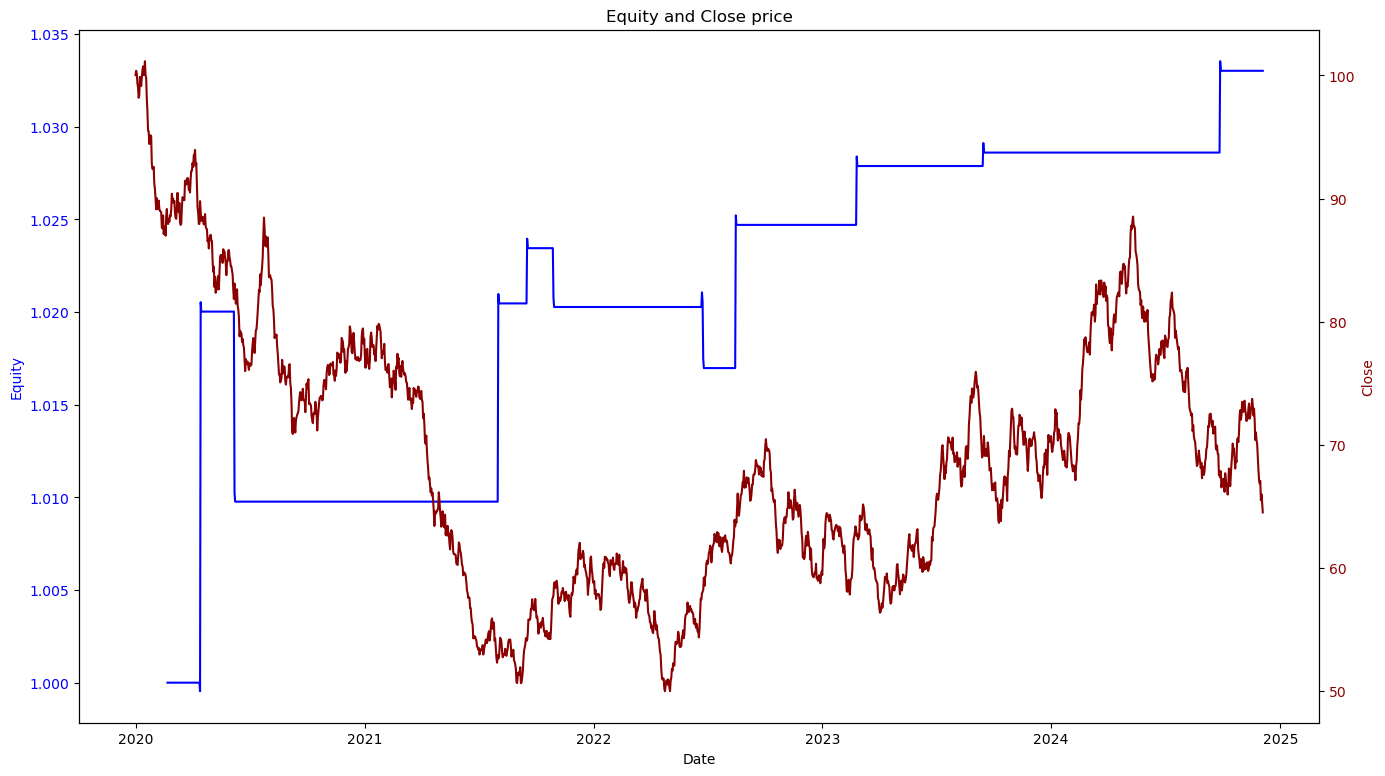

In [14]:
equity_df = pd.DataFrame(index=df.index[51:], data={"Equity": greedy_equity})
fig, ax1 = plt.subplots(figsize=(16, 9))
ax1.plot(equity_df, color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Equity", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax2 = ax1.twinx()
ax2.plot(df, color="darkred")
ax2.set_ylabel("Close", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")
plt.title("Equity and Close price")
plt.show()